In [5]:
# 1. Install & Load Environment
!pip install --pre deepmimo
import numpy as np
import tensorflow as tf
import deepmimo as dm
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers, callbacks
import pandas as pd
import matplotlib.pyplot as plt

In [6]:

# 2. Download and Load San Francisco (3 BSs)
scen_name = "city_16_sanfrancisco_3p5"
dm.download(scen_name)
dataset = dm.load(scen_name)

# 3. Configure Channel Generation
ch_params = dm.ChannelParameters()
ch_params.bs_antenna.shape = [8, 1]
dataset.compute_channels(ch_params)


Scenario "city_16_sanfrancisco_3p5" already exists in /content/deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 41808)
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 41808)
Loading TXRX PAIR: TXset 3 (tx_idx 0) & RXset 0 (rx_idxs 41808)
No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 41808/41808 [00:14<00:00, 2855.43it/s] 


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 41808/41808 [00:03<00:00, 10781.06it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 41808/41808 [00:09<00:00, 4308.15it/s]


[array([[[[ 3.0451506e-06-7.2553593e-07j],
          [-2.8244683e-06-1.4139562e-06j],
          [ 1.2049363e-06+2.9094276e-06j],
          ...,
          [ 3.0751596e-06+6.1454756e-07j],
          [-1.9642573e-06-2.5807087e-06j],
          [-2.7431503e-07+3.3687634e-06j]]],
 
 
        [[[ 1.1920289e-07+3.1904740e-06j],
          [ 1.9805809e-06-2.6714779e-06j],
          [-3.2376086e-06+1.0083137e-06j],
          ...,
          [-2.1458808e-07+2.9601354e-06j],
          [ 1.8164449e-06-1.8851081e-06j],
          [-2.6826642e-06+6.7278847e-08j]]],
 
 
        [[[-4.8903944e-06-2.4869605e-06j],
          [ 5.0866238e-06+5.0776675e-06j],
          [-3.6883921e-06-7.6105011e-06j],
          ...,
          [-5.1496522e-06+7.0400033e-06j],
          [ 6.4406076e-06-4.5233651e-06j],
          [-6.1662822e-06+2.1670173e-06j]]],
 
 
        ...,
 
 
        [[[ 2.0347089e-10-3.2062104e-09j],
          [ 3.5354338e-11+3.2124656e-09j],
          [-2.7398406e-10-3.2009559e-09j],
          ...,
  

In [7]:
# ---------------------------------------------------------
# 4. Helper Functions for Local Processing
# ---------------------------------------------------------

def get_local_data(dataset, bs_idx, num_ant=8, num_beams=16):
    """Extracts CSI and generates labels for a single specific BS."""
    # Create Local DFT Codebook
    cb = np.zeros((num_ant, num_beams), dtype=complex)
    for q in range(num_beams):
        cb[:, q] = np.exp(-1j * 2 * np.pi * q * np.arange(num_ant) / num_beams) / np.sqrt(num_ant)

    # 1. Get CSI for this BS: (Users, Antennas)
    csi_raw = dataset[bs_idx].channel.squeeze()

    # 2. Local Preprocessing (Real/Imag)
    X = np.stack([np.real(csi_raw), np.imag(csi_raw)], axis=-1)
    norms = np.max(np.abs(X), axis=(1, 2), keepdims=True) + 1e-9
    X_processed = X / norms

    # 3. Local Labels (Best beam index 0-15 for THIS BS)
    powers = np.abs(np.conj(csi_raw) @ cb)**2
    y_labels = np.argmax(powers, axis=1)

    return X_processed, y_labels, csi_raw, cb

def build_local_model():
    """Builds a regularized CNN for local beam prediction."""
    model = tf.keras.Sequential([
        layers.Input(shape=(8, 2, 1)), # Single BS input
        layers.Conv2D(32, (3, 2), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(16, activation='softmax') # 16 Local Beams
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
# ---------------------------------------------------------
# 5. Training Loop for 3 Independent Models
# ---------------------------------------------------------

bs_models = []
bs_results = {}

for i in range(len(dataset)):
    print(f"\n{'='*30}\nTRAINING MODEL FOR BASE STATION {i+1}\n{'='*30}")

    # Get local data for this specific BS
    X, y, csi_raw, cb = get_local_data(dataset, bs_idx=i)

    # Reshape X to include channel dimension for CNN: (N, 8, 2, 1)
    X = X[..., np.newaxis]

    # Split
    X_train, X_test, y_train, y_test, _, csi_test = train_test_split(
        X, y, csi_raw, test_size=0.2, random_state=42
    )

    # Train
    model = build_local_model()
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=20, batch_size=128,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    # Evaluate Efficiency
    y_pred = np.argmax(model.predict(X_test), axis=1)

    pred_gains = np.array([np.abs(np.conj(csi_test[j]).dot(cb[:, y_pred[j]]))**2 for j in range(len(y_test))])
    opt_gains = np.array([np.abs(np.conj(csi_test[j]).dot(cb[:, y_test[j]]))**2 for j in range(len(y_test))])
    efficiency = (np.mean(pred_gains) / np.mean(opt_gains)) * 100

    bs_models.append(model)
    bs_results[f"BS_{i+1}"] = efficiency
    print(f"BS {i+1} Local Beamforming Efficiency: {efficiency:.2f}%")

# ---------------------------------------------------------
# 6. Final Summary
# ---------------------------------------------------------
print("\n--- Final Multi-BS Performance ---")
for bs, eff in bs_results.items():
    print(f"{bs}: {eff:.2f}% Efficiency")


TRAINING MODEL FOR BASE STATION 1
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
BS 1 Local Beamforming Efficiency: 96.89%

TRAINING MODEL FOR BASE STATION 2
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
BS 2 Local Beamforming Efficiency: 99.55%

TRAINING MODEL FOR BASE STATION 3
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
BS 3 Local Beamforming Efficiency: 99.41%

--- Final Multi-BS Performance ---
BS_1: 96.89% Efficiency
BS_2: 99.55% Efficiency
BS_3: 99.41% Efficiency



Running Global Inference...

--- Global Selection Results (Sample) ---
 User_ID  BS1_Beam  BS2_Beam  BS3_Beam  Best_BS_Selected
   35549         0         3         8                 1
   18441         5         7        12                 1
   31606         5         5         8                 1
   19832         0         0         0                 3
   18928         9         0         2                 3
   16869         8         0         1                 3
    3169         6         0         2                 3
   27607         5         0         9                 2
   12488        10         0         2                 3
   16594         5         6        12                 1
   21255         0         0         0                 3
   30589         8         0         2                 3
    2304         8         0         2                 3
   19960         5         3         8                 1
   25013         5         0        12                 1


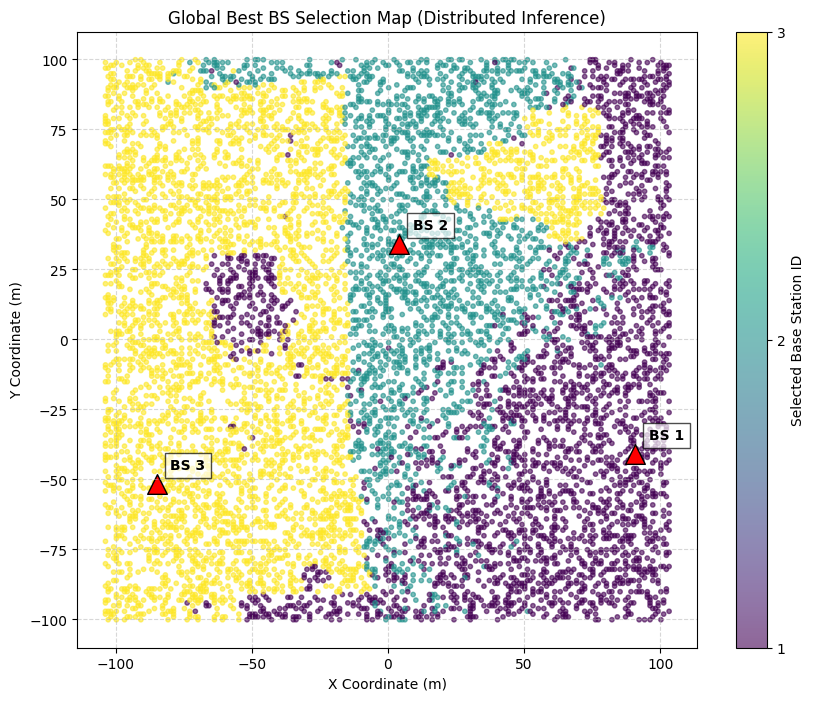

In [9]:
import pandas as pd

# ---------------------------------------------------------
# 7. Global Inference & Handover Logic
# ---------------------------------------------------------

# We need the test indices to extract the correct coordinates for mapping
# Since random_state=42 was used in the loop, these indices are consistent
num_users = dataset[0].rx_pos.shape[0]
train_idx, test_idx = train_test_split(np.arange(num_users), test_size=0.2, random_state=42)

all_bs_predicted_beams = []
all_bs_predicted_powers = []

print("\nRunning Global Inference...")

for i in range(len(dataset)):
    # 1. Re-extract the local test data for this BS
    X, _, csi_raw, cb = get_local_data(dataset, bs_idx=i)
    X_test_local = X[test_idx][..., np.newaxis]
    csi_test_local = csi_raw[test_idx]

    # 2. Perform Inference
    y_probs = bs_models[i].predict(X_test_local, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)
    all_bs_predicted_beams.append(y_pred)

    # 3. Calculate the actual Power achieved by the predicted beam
    # Power = |h^H * w|^2
    current_bs_powers = np.array([
        np.abs(np.conj(csi_test_local[j]).dot(cb[:, y_pred[j]]))**2
        for j in range(len(y_pred))
    ])
    all_bs_predicted_powers.append(current_bs_powers)

# 4. Determine Global Best BS per user (which BS provides the max power?)
powers_matrix = np.stack(all_bs_predicted_powers, axis=1) # Shape: (Test_Users, 3)
global_best_bs_indices = 3-np.argmax(powers_matrix, axis=1)  # Convert 0-2 to 1-3

# ---------------------------------------------------------
# 8. Visualization & Summary Table
# ---------------------------------------------------------

# Create a summary table for the first 15 test users
summary_df = pd.DataFrame({
    'User_ID': test_idx[:15],
    'BS1_Beam': all_bs_predicted_beams[0][:15],
    'BS2_Beam': all_bs_predicted_beams[1][:15],
    'BS3_Beam': all_bs_predicted_beams[2][:15],
    'Best_BS_Selected': global_best_bs_indices[:15]
})

print("\n--- Global Selection Results (Sample) ---")
print(summary_df.to_string(index=False))

# Map visualization
test_coords = dataset[0].rx_pos[test_idx]
plt.figure(figsize=(10, 8))
scatter = plt.scatter(test_coords[:, 0], test_coords[:, 1],
                      c=global_best_bs_indices, cmap='viridis', s=10, alpha=0.6)

# Plot BS locations for context
for i in range(len(dataset)):
    pos = dataset[i].tx_pos[0]
    plt.scatter(pos[0], pos[1], marker='^', s=200, color='red', edgecolors='black')
    plt.text(pos[0]+5, pos[1]+5, f'BS {3-i}', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

plt.colorbar(scatter, ticks=[1, 2, 3], label='Selected Base Station ID')
plt.title("Global Best BS Selection Map (Distributed Inference)")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
# Updated Top-k evaluation to match your reversed naming (BS 1 <-> BS 3)
def evaluate_top_k_fixed(bs_models, dataset, test_idx):
    top_k_results = []
    num_bs = len(dataset)

    for i in range(num_bs):
        # Local data for dataset[i]
        X, y, _, _ = get_local_data(dataset, bs_idx=i)
        X_test = X[test_idx][..., np.newaxis]
        y_test = y[test_idx]

        y_probs = bs_models[i].predict(X_test, verbose=0)

        # Standard Accuracies
        top1 = np.mean(tf.keras.metrics.sparse_categorical_accuracy(y_test, y_probs))
        top3 = np.mean(tf.keras.metrics.sparse_top_k_categorical_accuracy(y_test, y_probs, k=3))

        # Use your 3 - i mapping for the display name
        top_k_results.append({
            'Display_Name': f'BS {3-i}',
            'Top-1 (%)': top1 * 100,
            'Top-3 (%)': top3 * 100
        })

    return pd.DataFrame(top_k_results).sort_values('Display_Name')

# Run and Print
acc_summary = evaluate_top_k_fixed(bs_models, dataset, test_idx)
print(acc_summary.to_string(index=False))

Display_Name  Top-1 (%)  Top-3 (%)
        BS 1  95.682854  99.916283
        BS 2  97.620186  99.928246
        BS 3  97.572350  99.916283


In [11]:
from google.colab import files
import os

# Create a folder to keep things tidy
model_dir = "trained_models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print("Saving and downloading models...")

for i, model in enumerate(bs_models):
    # Use your fixed naming logic (3-i) for the filename
    bs_name = f"BS_{3-i}"
    filename = f"{model_dir}/san_fran_{bs_name}_model.keras"

    # 1. Save the model locally in Colab
    model.save(filename)
    print(f"Saved: {filename}")

    # 2. Trigger the download to your computer
    files.download(filename)


Saving and downloading models...
Saved: trained_models/san_fran_BS_3_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: trained_models/san_fran_BS_2_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: trained_models/san_fran_BS_1_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>